In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
import os
import sys

import cv2

import numpy as np 

import torch
import torch.nn as nn
import torch.nn.functional as F

from box import Box
import yaml

import matplotlib.pyplot as plt

from scipy.spatial.transform import Rotation as R
import random 

import time 

root_dir = os.path.abspath('../..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.models.dpso_inference import DPSO

from src.data_loader.evaluation_data_generator import DataGenerator

In [18]:
model_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/model.yaml'
sonar_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/sonar.yaml'
train_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/training.yaml'


# root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/train/seq_1'
root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/SonarOdometryDataset/train/seq_5'
transforms = None


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_gen = DataGenerator(root_dir, device)


t, frame, pose = data_gen.get_sample(0)

print(t.shape)
print(frame.shape)
print(pose.shape)



torch.Size([1])
torch.Size([1, 1, 1, 800, 768])
torch.Size([7])


In [19]:
output_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/test'
dpso = DPSO(model_config_pth, sonar_config_pth, output_pth, save_to_file = True)

samples_num = data_gen.get_len()

iter = 20
if iter > samples_num: iter = samples_num

exec_t_sum = 0
eps = 1e-5
torch.autograd.set_detect_anomaly(False)
with torch.no_grad():
    for i in range(iter):

        time_1 = time.time()
        t, frame, pose_gt = data_gen.get_sample(i)
        if i < 1:
            dpso.set_init_pose(frame, t, pose_gt)
        else:
            pose_pred = dpso(frame, t)
        time_2 = time.time()

        exec_t_sum += time_2 - time_1

print(f'execution time (mean): {exec_t_sum/i}')
dpso.close()

execution time (mean): 0.9985770175331518


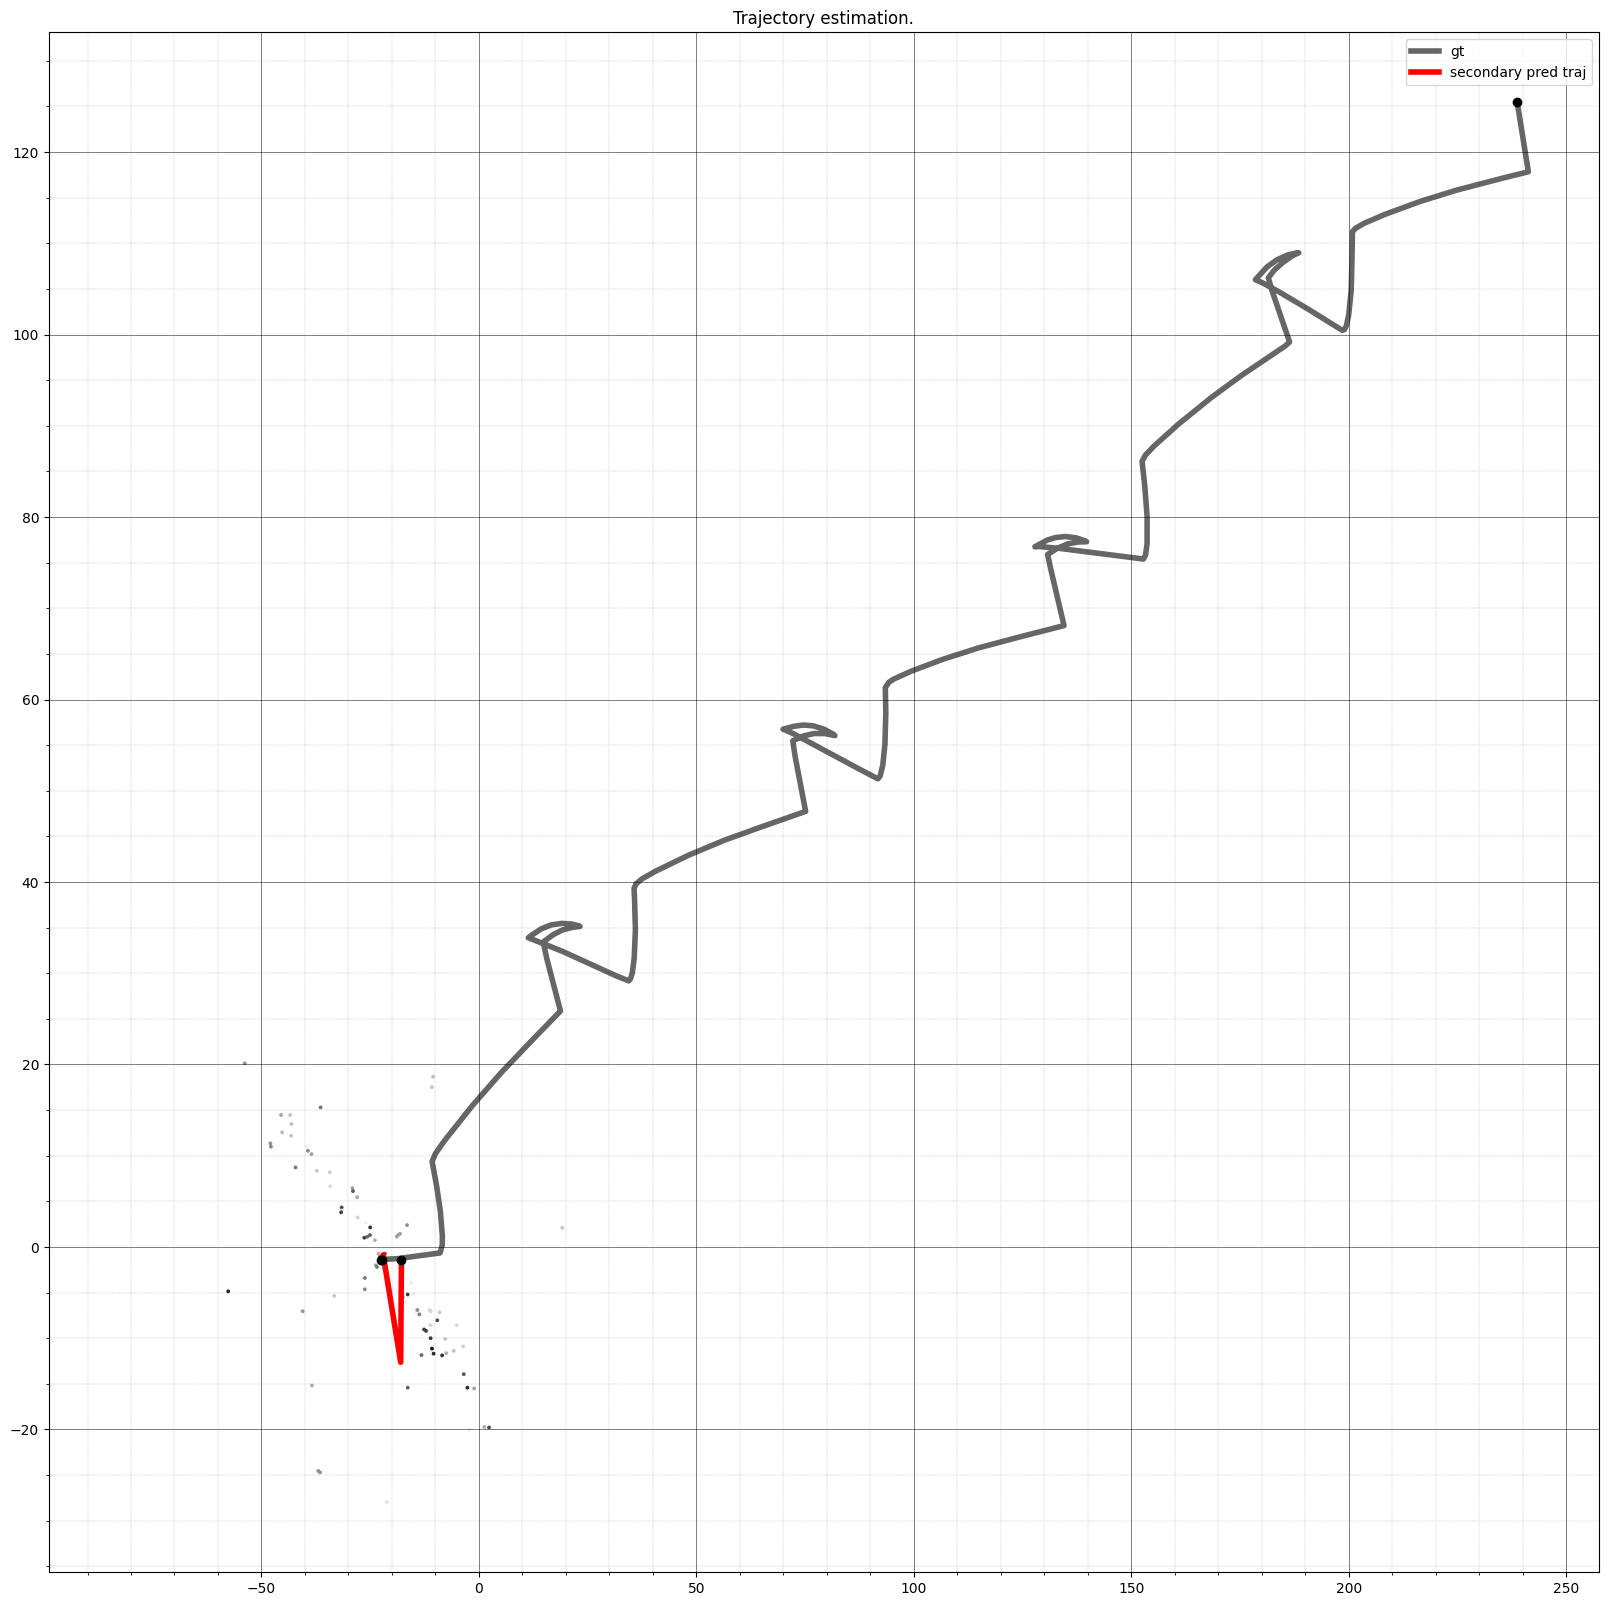

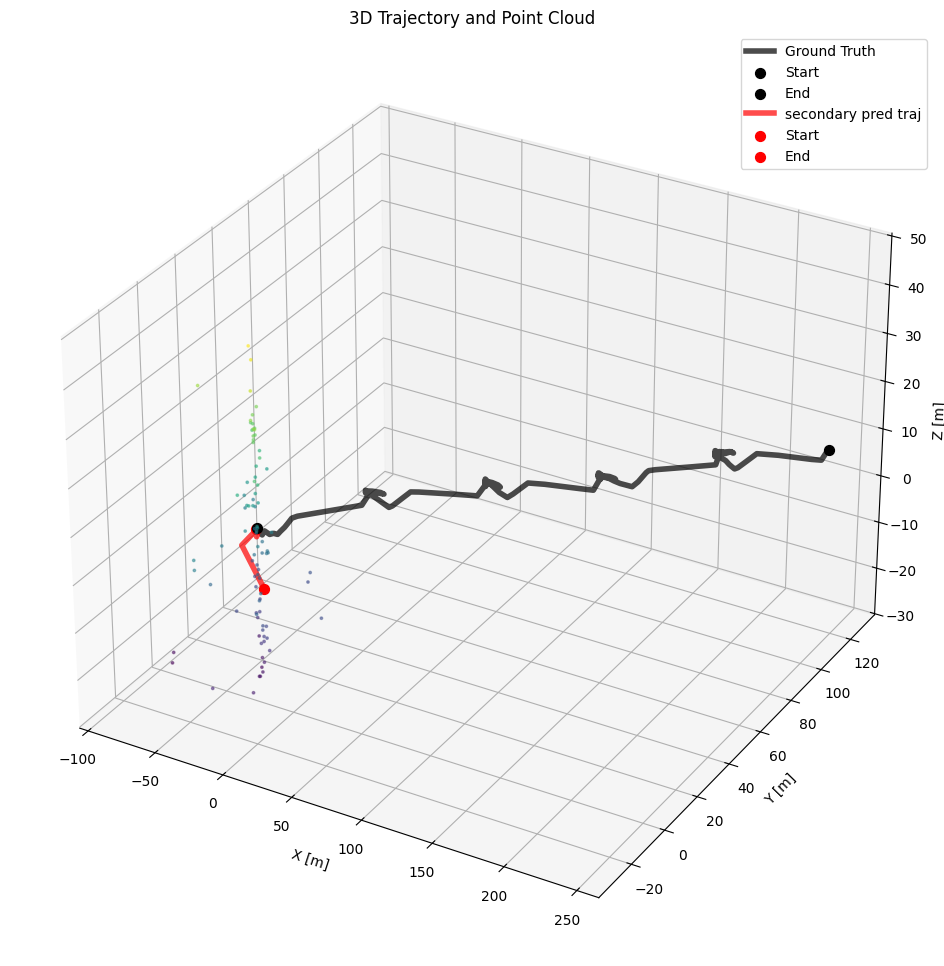

In [20]:

data_gen.read_estim_trajectory('C:/Users/janis/Projekty/Magisterka/SonarOdometry/test/trajectory_secondary_estimation.csv', 'secondary pred traj')
data_gen.read_pts('C:/Users/janis/Projekty/Magisterka/SonarOdometry/test/3d_points_estimation.csv')
data_gen.generate_trajectory_map_2d(plane = 'xy', 
                                    show = {'gt':True,'traj':True,'pts':True}, 
                                    start = 0, end = 1, 
                                    colors = ('red', 'green', 'blue', 'orange'), 
                                    traj_width = 4, pt_size = 3, 
                                    save_to_file = None)
data_gen.generate_trajectory_map_3d(show = {'gt':True,'traj':True,'pts':True}, 
                                    start = 0, end = 1, 
                                    colors = ('red', 'green', 'blue', 'orange'), 
                                    traj_width = 4, pt_size = 3, 
                                    save_to_file = None)
